# Config

In [1]:
!git config --global --add safe.directory /tmp/Repository/VRID_language_proyect

In [2]:
import os

# Ruta a la que quieres mover el path
nueva_ruta = "/tmp/Repository/VRID_language_proyect/BERT"

# Cambiar el directorio actual
os.chdir(nueva_ruta)

# Confirmar que cambió
print("Directorio actual:", os.getcwd())

Directorio actual: /tmp/Repository/VRID_language_proyect/BERT


# 1) Split dataset

In [6]:
from utils.dataset import get_dataset_to_split, split_dataset
import pandas as pd
import numpy as np
import os

#Save data
path = "/tmp/final_project"
filepath = os.path.join(path, "datasets/features_2.csv")
df=pd.read_csv(filepath)

feat_col = "Interdisciplinario"
df = get_dataset_to_split(df, feat_col)

#Eliminar elementos indefinidos 
df = df[df["Interdisciplinario"]!="INDEFINIDO"]

#Split data and save idx
ids = np.array(df["Código VRID"])
labels = np.array(df["Interdisciplinario"])
savepath = os.path.join(path, "dataSplits/interdiciplinario/train_test_ids_3folds.json")
split_dataset(savepath, ids, labels)

Test size: 193
Fold 0 - Val size: 257
Archivo guardado exitosamente en /tmp/final_project/dataSplits/interdiciplinario/train_test_ids_3folds.json


# 2) Entrenamiento TF-IDF

### Carga y entrenamiento

In [14]:
import json
import pandas as pd

#Ruta de lectura
path = "/tmp/final_project"

#Lectura de index de separacion de conjuntos train/test
filepath=os.path.join(path, "dataSplits/interdiciplinario/train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "datasets/data_translated_2.csv")
df = pd.read_csv(filepath)


In [73]:
#################################### ESTO ES PARA TESTEAR DATOS ANTIGUOS #########################
#Ruta de lectura
path2 = "/tmp/data"

#Lectura de index de separacion de conjuntos train/test
filepath=os.path.join(path2, "train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path2, "data_translated_concat.csv")
df = pd.read_csv(filepath)


In [15]:
from sklearn.preprocessing import LabelEncoder
from utils.dataset import gen_dataset_select_cols
from models.TIFD import gen_TFID_vectors
import numpy as np

#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]

#Lectura de codigos VRID Test
codes_test = dataset_index["Test"]
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                 test_col="Interdisciplinario")
sample = X_test[0]
#Lectura de codigos VRID Train
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset_select_cols(codes_train, df, cols = cols,
                                                      test_col="Interdisciplinario")
df_decode = df_train[["idx", "Código VRID"]]

# Codificación de labels
y_train = [1 if x == "SI" else 0 for x in y_train]
y_test = [1 if x == "SI" else 0 for x in y_test]

#Creacion de vectores TFID
X_train, X_test, vectorizer = gen_TFID_vectors(X_train, X_test, return_vectorizer=True)
print(X_train.shape, X_test.shape)

(771, 16326) (193, 16326)


In [16]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model
from utils.dataset import CvCustom
from collections import Counter
import warnings
warnings.filterwarnings(
    "ignore",
    message="The objective has been evaluated at point",
    category=UserWarning,
    module="skopt.optimizer.optimizer"
)


# 1. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    'RandomForestClassifier',
    'XGBClassifier',
    'SVC',
]

# 2. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)
print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))

# 3. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring='f1_macro'
split_idx_path = os.path.join(path, "dataSplits/interdiciplinario/train_test_ids_3folds.json")
#split_idx_path = os.path.join(path2, "train_test_ids_3folds.json")
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode, split_idx_path), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 4. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({1: 444, 0: 327})
📊 test: Counter({1: 111, 0: 82})
(771,)
LogisticRegression
Compute sw
RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.63, 'std_test_score': 0.02}
RandomForestClassifier: {'mean_test_score': 0.62, 'std_test_score': 0.04}
XGBClassifier: {'mean_test_score': 0.6, 'std_test_score': 0.01}
SVC: {'mean_test_score': 0.63, 'std_test_score': 0.03}


In [17]:
from utils.mlflow import eval_model

# Métricas por idioma
lang_es = df_test["Español"]
results_test, preds_test = {}, {}
for name, model in models_dicc.items():
    print(name)
    results, preds = eval_model(model, X_test, y_test, lang_es)
    print(results)
    results_test[name] = results
    preds_test[name] = preds

LogisticRegression
{'accuracy': 0.6321243523316062, 'f1_macro': 0.6263463583562839, 'cm': array([[49, 33],
       [38, 73]]), 'precision': 0.6886792452830188, 'recall': 0.6576576576576577, 'f1_es': 0.6375284049702655, 'f1_en': 0.6142234843263212, 'cm_es': array([[22, 23],
       [19, 53]]), 'cm_en': array([[27, 10],
       [19, 20]])}
RandomForestClassifier
{'accuracy': 0.6113989637305699, 'f1_macro': 0.6052954489679055, 'cm': array([[47, 35],
       [40, 71]]), 'precision': 0.6698113207547169, 'recall': 0.6396396396396397, 'f1_es': 0.6059550043560703, 'f1_en': 0.5680939637228665, 'cm_es': array([[16, 29],
       [15, 57]]), 'cm_en': array([[31,  6],
       [25, 14]])}
XGBClassifier
{'accuracy': 0.5751295336787565, 'f1_macro': 0.5404761904761904, 'cm': array([[29, 53],
       [29, 82]]), 'precision': 0.6074074074074074, 'recall': 0.7387387387387387, 'f1_es': 0.5633314054366685, 'f1_en': 0.5129049897470951, 'cm_es': array([[ 9, 36],
       [ 9, 63]]), 'cm_en': array([[20, 17],
       [2

### Guardado de resultados

In [13]:
from utils.save_results import save_models_and_metrics
from utils.save_results import model_to_pipeline

savepath = os.path.join(path, "output/interdiciplinario/TF_IDF")
models_dicc_pipeline = model_to_pipeline(vectorizer, models_dicc)
save_models_and_metrics(savepath, results_val, models_dicc_pipeline, df_test, y_test, results_test, preds_test, save_preds=True, mode_classification="binary")

📝 Registrando modelo: LogisticRegression
📝 Registrando modelo: RandomForestClassifier


/tmp/Repository/VRID_language_proyect/BERT/utils/save_results.py:197: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["y_true"]=y_test
/tmp/Repository/VRID_language_proyect/BERT/utils/save_results.py:198: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["preds"]=preds_test[model_name]


📝 Registrando modelo: XGBClassifier
📝 Registrando modelo: SVC


### Inference

In [59]:
from utils.save_results import load_model

model_path = "/tmp/final_project/output/interdiciplinario/TF_IDF/models"
model_path = os.path.join(model_path)

# Por defecto, carga el mejor modelo especificado en archivo txt
inference_model = load_model(model_path)
sample = 'role of plant-bacterial interaction under over-irrigated conditions on the hydric relationships of plants and the maturation rates of kiwi fruits (delicous actinidia) from the regulation of the synthesis of ethylene precursors flooding, ethylene, plant water status, hypoxia, fruit quality, fruit softening over-watering is a very common practice in agriculture, despite the severe water crisis that affects chili. the effects generated by the lack of oxygenation in the roots of the plants are not usually considered by the farmers, since the high plasticity of the plant organisms to the different biotic and abiotic stresses can hide the real economic impact of the excessive application of water. the kiwi (actinidia delicious chev.) is a fruit of importance in chile, because we are the third exporter worldwide. unfortunately, because this fruit plant has its center of origin in the forests of monsoon climate of china, a large quantity of water is applied in the commercial orchards, many times up to the double the maximum water requirement of the cultivation. the kiwi is considered a fruit crop not tolerant to all-negmentation, and therefore, its mechanisms of escape or tolerance to the absence of oxygen of the roots due to the excess of water are poor in comparison with other fruit species. in this context, the synthesis and accumulation of ethylene in the plant organs has been associated with the physiological responses ki. . however, by allowing fruit to mature at 20°c for a week, the kiwis of over-regulated plants showed a higher level of softening and concentration of soluble solids than plants under optimal irrigation, clearly indicating a higher rate of maturation in the fruit of plants under abundant irrigation, and therefore a higher concentration of the ethylene in the fruits. against this, it is necessary to ask how it is possible that in a state of initial maturity there has not been differences in maturating between irrigation treatments, but once the fruit was harvested if they could be detected. a potential response falls in the synthesis of the precursors of ethylene, particularly the 1-aminopropane-1-carboxylic acid (acc), which has been found in higher concentrations in other tropical cultures susceptible to hypoxia and tropical origin. bacterial populations associated with the rizosphere and roots of plants, can be affected as a consequence of the anaerobic conditions generated by the neutralization. in particular the group of bacteria producing the enzyme acc-deaminase play an important role in the regulation of the effects of the soil and ethylene and roots.'
pred = inference_model.predict([sample])
print("Prediction:", pred)

Mejor modelo: SVC
Prediction: [1]


In [60]:
#from utils.save_results import load_model

metrics_path = "/tmp/final_project/output/interdiciplinario/TF_IDF/metrics"
metrics_path = os.path.join(metrics_path, "SVC.json")#, "SVC.joblib")

with open(metrics_path, "r", encoding="utf-8") as f:
    metrics = json.load(f)

print("📊 Métricas cargadas:")
print(metrics)

📊 Métricas cargadas:
{'val_mean_test_score': 0.65, 'val_std_test_score': 0.04, 'test_accuracy': 0.6994818652849741, 'test_f1_macro': 0.6925401010766865, 'test_precision': 0.7387387387387387, 'test_recall': 0.7387387387387387, 'test_f1_es': 0.6755460642164025, 'test_f1_en': 0.7378935532233882, 'git_commit': '6d8d31f7f21b2bbc400fe6bf671f1701c4d5c335'}


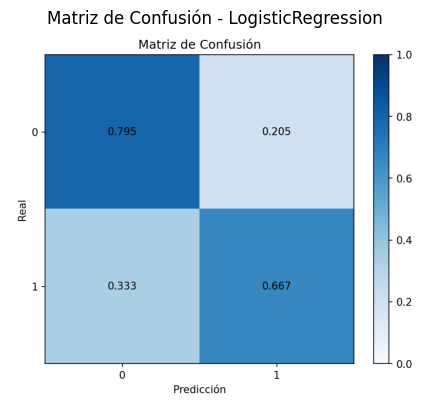

In [61]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

metrics_path = "/tmp/final_project/output/interdiciplinario/TF_IDF/metrics"
cm_path = os.path.join(metrics_path, "cm_SVC.png")

# Mostrar la imagen
img = mpimg.imread(cm_path)
plt.imshow(img)
plt.axis("off")
plt.title("Matriz de Confusión - LogisticRegression")
plt.show()


### MLFLOW (para hacer reporte de resultados)

In [62]:
from utils.mlflow import mlflow_ckeckpoint

exp_info = {
    'exp_name': "final_project_interdiciplinario",
}

extra_parms = {
    "vectorization_model": "TF-IDF",
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring,
    "cols": cols
}

extra_artifacts = {
    "dataset_data_splits": dataset_index,
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, X_test, y_test, df_test, save_preds=True, lang_es=lang_es, extra_parms=extra_parms, extra_artifacts=extra_artifacts, mode="server", mode_classification="binary")

Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/09/27 22:49:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/25/runs/cf8c21b125024edcaf703e29deabd1e8
🧪 View experiment at: http://mlflow-server:5000/#/experiments/25
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/09/27 22:49:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/25/runs/a5bfe566979d430aadfe17a4516c43d1
🧪 View experiment at: http://mlflow-server:5000/#/experiments/25
📝 Registrando modelo en MLflow: XGBClassifier


2025/09/27 22:49:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/25/runs/61eccdf84e1741149eb60b058ab1059e
🧪 View experiment at: http://mlflow-server:5000/#/experiments/25
📝 Registrando modelo en MLflow: SVC


2025/09/27 22:50:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/25/runs/d6c734aae0194ff1a783d80cf1cae302
🧪 View experiment at: http://mlflow-server:5000/#/experiments/25


# 3) SPECTER

### Train

In [44]:
import json
import pandas as pd

#Ruta de lectura
path = "/tmp/final_project"

#Lectura de index de separacion de conjuntos train/test
filepath=os.path.join(path, "dataSplits/interdiciplinario/train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
filepath=os.path.join(path, "datasets/data_translated.csv")
df = pd.read_csv(filepath)

In [ ]:
#################################### ESTO ES PARA TESTEAR PARTICIONES ANTIGUAS #########################
#Lectura de index de separacion de conjuntos train/test
filepath=os.path.join(path2, "train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

In [46]:
from utils.dataset import gen_dataset_select_cols
from models.specter import embed_texts
import numpy as np

#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]

#Lectura de codigos VRID Test
codes_test = dataset_index["Test"]
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, 
                                                 test_col="Interdisciplinario")

#Lectura de codigos VRID Train
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset_select_cols(codes_train, df, cols = cols,
                                                      test_col="Interdisciplinario")
df_decode = df_train[["idx", "Código VRID"]]

# Codificación de labels
y_train = [1 if x == "SI" else 0 for x in y_train]
y_test = [1 if x == "SI" else 0 for x in y_test]

# Calcular embeddings
# Parámetros para cargar modelo
BASE_MODEL = "allenai/specter2_base"
ADAPTER_NAME="allenai/specter2_classification"
X_train = embed_texts(X_train, BASE_MODEL, ADAPTER_NAME)
X_test = embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)

print(X_train.shape, X_test.shape)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(771, 768) (193, 768)


In [47]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model
from utils.dataset import CvCustom
from collections import Counter
import warnings
warnings.filterwarnings(
    "ignore",
    message="The objective has been evaluated at point",
    category=UserWarning,
    module="skopt.optimizer.optimizer"
)

# 1. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    'RandomForestClassifier',
    'XGBClassifier',
    'SVC',
]

# 2. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)
print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))

# 3. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring='f1_macro'
split_idx_path = os.path.join(path, "dataSplits/interdiciplinario/train_test_ids_3folds.json")
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode, split_idx_path), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 4. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({1: 444, 0: 327})
📊 test: Counter({1: 111, 0: 82})
(619,)
LogisticRegression
Compute sw


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.64, 'std_test_score': 0.01}
RandomForestClassifier: {'mean_test_score': 0.62, 'std_test_score': 0.01}
XGBClassifier: {'mean_test_score': 0.6, 'std_test_score': 0.01}
SVC: {'mean_test_score': 0.65, 'std_test_score': 0.02}


In [48]:
from utils.mlflow import eval_model

# Métricas por idioma
lang_es = df_test["Español"]
results_test, preds_test = {}, {}
for name, model in models_dicc.items():
    print(name)
    results, preds = eval_model(model, X_test, y_test, lang_es)
    print(results)
    results_test[name] = results
    preds_test[name] = preds

LogisticRegression
{'accuracy': 0.6373056994818653, 'f1_macro': 0.6300657174151151, 'cm': array([[48, 34],
       [36, 75]]), 'precision': 0.6880733944954128, 'recall': 0.6756756756756757, 'f1_es': 0.6149433510517792, 'f1_en': 0.6583795782463929, 'cm_es': array([[17, 26],
       [21, 60]]), 'cm_en': array([[31,  8],
       [15, 15]])}
RandomForestClassifier
{'accuracy': 0.6735751295336787, 'f1_macro': 0.6631202726290416, 'cm': array([[48, 34],
       [29, 82]]), 'precision': 0.7068965517241379, 'recall': 0.7387387387387387, 'f1_es': 0.6521949371883088, 'f1_en': 0.6714630162557362, 'cm_es': array([[16, 27],
       [14, 67]]), 'cm_en': array([[32,  7],
       [15, 15]])}
XGBClassifier
{'accuracy': 0.6735751295336787, 'f1_macro': 0.6618084721720023, 'cm': array([[47, 35],
       [28, 83]]), 'precision': 0.7033898305084746, 'recall': 0.7477477477477478, 'f1_es': 0.6488530027243653, 'f1_en': 0.6932790914484279, 'cm_es': array([[17, 26],
       [16, 65]]), 'cm_en': array([[30,  9],
       [1

### Guardado de resultados

In [49]:
from utils.save_results import save_models_and_metrics
from utils.save_results import model_to_pipeline
from models.specter import BERT_vectorizer

savepath = os.path.join(path, "output/interdiciplinario/SPECTER")
vectorizer = BERT_vectorizer(BASE_MODEL, ADAPTER_NAME)
models_dicc_pipeline = model_to_pipeline(vectorizer, models_dicc)
save_models_and_metrics(savepath, results_val, models_dicc_pipeline, df_test, y_test, results_test, preds_test, save_preds=True, mode_classification="binary")

📝 Registrando modelo: LogisticRegression
📝 Registrando modelo: RandomForestClassifier


/tmp/Repository/VRID_language_proyect/BERT/utils/save_results.py:197: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["y_true"]=y_test
/tmp/Repository/VRID_language_proyect/BERT/utils/save_results.py:198: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["preds"]=preds_test[model_name]


📝 Registrando modelo: XGBClassifier
📝 Registrando modelo: SVC


### Inference

In [50]:
from utils.save_results import load_model

model_path = "/tmp/final_project/output/interdiciplinario/SPECTER/models"
model_path = os.path.join(model_path)

inference_model = load_model(model_path)
sample = 'role of plant-bacterial interaction under over-irrigated conditions on the hydric relationships of plants and the maturation rates of kiwi fruits (delicous actinidia) from the regulation of the synthesis of ethylene precursors flooding, ethylene, plant water status, hypoxia, fruit quality, fruit softening over-watering is a very common practice in agriculture, despite the severe water crisis that affects chili. the effects generated by the lack of oxygenation in the roots of the plants are not usually considered by the farmers, since the high plasticity of the plant organisms to the different biotic and abiotic stresses can hide the real economic impact of the excessive application of water. the kiwi (actinidia delicious chev.) is a fruit of importance in chile, because we are the third exporter worldwide. unfortunately, because this fruit plant has its center of origin in the forests of monsoon climate of china, a large quantity of water is applied in the commercial orchards, many times up to the double the maximum water requirement of the cultivation. the kiwi is considered a fruit crop not tolerant to all-negmentation, and therefore, its mechanisms of escape or tolerance to the absence of oxygen of the roots due to the excess of water are poor in comparison with other fruit species. in this context, the synthesis and accumulation of ethylene in the plant organs has been associated with the physiological responses ki. . however, by allowing fruit to mature at 20°c for a week, the kiwis of over-regulated plants showed a higher level of softening and concentration of soluble solids than plants under optimal irrigation, clearly indicating a higher rate of maturation in the fruit of plants under abundant irrigation, and therefore a higher concentration of the ethylene in the fruits. against this, it is necessary to ask how it is possible that in a state of initial maturity there has not been differences in maturating between irrigation treatments, but once the fruit was harvested if they could be detected. a potential response falls in the synthesis of the precursors of ethylene, particularly the 1-aminopropane-1-carboxylic acid (acc), which has been found in higher concentrations in other tropical cultures susceptible to hypoxia and tropical origin. bacterial populations associated with the rizosphere and roots of plants, can be affected as a consequence of the anaerobic conditions generated by the neutralization. in particular the group of bacteria producing the enzyme acc-deaminase play an important role in the regulation of the effects of the soil and ethylene and roots.'
pred = inference_model.predict([sample])
print("Prediction:", pred)

Mejor modelo: RandomForestClassifier


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
Prediction: [1]


### MLFLOW (para hacer reporte de resultados)

In [52]:
from utils.mlflow import mlflow_ckeckpoint

exp_info = {
    'exp_name': "final_project_interdiciplinario",
}

extra_parms = {
    "vectorization_model": "SPECTER",
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring,
    "cols": cols
}

extra_artifacts = {
    "dataset_data_splits": dataset_index,
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, X_test, y_test, df_test, save_preds=True, lang_es=lang_es, extra_parms=extra_parms, extra_artifacts=extra_artifacts, mode="server", mode_classification="binary")

2025/09/27 22:45:12 INFO mlflow.tracking.fluent: Experiment with name 'final_project_interdiciplinario' does not exist. Creating a new experiment.


Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/09/27 22:45:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/25/runs/2e97f1f93f9f4dbfb7aaade600bd3619
🧪 View experiment at: http://mlflow-server:5000/#/experiments/25
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/09/27 22:45:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/25/runs/05ca6b296854470a8d5884cf1c1f30b4
🧪 View experiment at: http://mlflow-server:5000/#/experiments/25
📝 Registrando modelo en MLflow: XGBClassifier


2025/09/27 22:45:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/25/runs/fe4fd1d223964cd8b3f2212e2ee65704
🧪 View experiment at: http://mlflow-server:5000/#/experiments/25
📝 Registrando modelo en MLflow: SVC


2025/09/27 22:45:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/25/runs/513515df5e3a4e8480266a7942afd93d
🧪 View experiment at: http://mlflow-server:5000/#/experiments/25
